## Introducción
Este cuaderno recoge todo el proceso necesario para llevar a cabo un modelo de inteligencia artificial predictor de partidos de futbol. En lugar de dar un solo resultado se mostrara el porcentaje de victoria local, vitoria visitante o empate.

Se usan 3 fuentes de datos:

1. **Football.co:** Resultados históricos y estadísticas básicas.
2. **Understat:** Métricas avanzadas de rendimiento (xG, xPoints, PPDA, Deep Completions).
3. **Transfermarkt:** Datos económicos, demográficos y tácticos (Valor de mercado, edades, entrenadores, formaciones).

Para mas información lea el readme.md del proyecto

In [ ]:
#Cargamos todos los csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import numpy as np
import tensorflow as tf

def fijar_semilla(seed=42):
    # 1. Fijar entorno de Python nativo
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # 2. Fijar NumPy (Crucial para split de datos y transformaciones)
    np.random.seed(seed)

    # 3. Fijar TensorFlow (Crucial para la inicialización de capas y Dropout)
    tf.random.set_seed(seed)

    print(f"✅ Semilla global fijada en: {seed}")

# Ejecutamos la función de inmediato
fijar_semilla(42)
from google.colab import drive
drive.mount('/content/drive')
df_lineups = pd.read_csv('/content/drive/MyDrive/football_data/game_lineups.csv')
df_clubs = pd.read_csv('/content/drive/MyDrive/football_data/clubs.csv')
df_players = pd.read_csv('/content/drive/MyDrive/football_data/players.csv')
df_player_valuations = pd.read_csv('/content/drive/MyDrive/football_data/player_valuations.csv')
df_games = pd.read_csv('/content/drive/MyDrive/football_data/games.csv')
df_appearances = pd.read_csv('/content/drive/MyDrive/football_data/appearances.csv')
df_football_co = pd.read_csv('/content/drive/MyDrive/football_data/data_football_co.csv')
df_understat = pd.read_csv('/content/drive/MyDrive/football_data/data_understats.csv')

✅ Semilla global fijada en: 42
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1163/1964482598.py:28: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lineups = pd.read_csv('/content/drive/MyDrive/football_data/game_lineups.csv')


In [ ]:
df_games.info()
df_lineups.info()
df_clubs.info()
df_players.info()
df_player_valuations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88271 entries, 0 to 88270
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 88271 non-null  int64  
 1   competition_id          88271 non-null  object 
 2   season                  88271 non-null  int64  
 3   round                   88271 non-null  object 
 4   date                    88271 non-null  object 
 5   home_club_id            88271 non-null  int64  
 6   away_club_id            88271 non-null  int64  
 7   home_club_goals         88271 non-null  int64  
 8   away_club_goals         88271 non-null  int64  
 9   home_club_position      62966 non-null  float64
 10  away_club_position      62966 non-null  float64
 11  home_club_manager_name  87426 non-null  object 
 12  away_club_manager_name  87426 non-null  object 
 13  stadium                 88029 non-null  object 
 14  attendance              77484 non-null

## Filtrado inicial

Puesto que nuestro modelo unicamente tiene como objetivo predecir LaLiga, trabajaremos unicamente con datos de la liga española. Se descargaron unicamente partidos de LaLiga de las 2 fuentes de datos restantes, por tanto este paso solo será necesario para los provenientes de Transfermarkt(kaagle)

In [ ]:

#Filtramos partidos solo de la liga Española
df_games_liga = df_games[
    (df_games['competition_id'] == 'ES1')
].copy()

#Hacemos una copia para no modificar los originales
df_games_fco = df_football_co.copy()

df_games_unstat = df_understat.copy()

#Filtramos el dataset de clubes, cogiendo solo los de la liga Española
df_clubs_tf = df_clubs[
    df_clubs['domestic_competition_id'] == 'ES1'
].copy()



## Renombrado de equipos

Para posteriormente poder unificar las distintas fuentes de datos, en la siguiente sección estandarizamos los nombres de los equipos.

In [ ]:
#Comprobamos que equipos hay presentes en el dataset de partidos de transfermarkt
tf_teams = pd.unique(pd.concat([df_games_liga['home_club_name'], df_games_liga['away_club_name']]))
# Hacemos lo mismo con understat

understat_teams = df_games_unstat['home_team'].unique()

#Generamos un dict con el que poder estandarizar los nombres de los equipos en ambos datasets

rename_dict = {
     # Nombres de transfermarkt : Nombre Estándar (Understat)
    'Real Sociedad de Fútbol S.A.D.': 'Real Sociedad',
    'Club Atlético Osasuna': 'Osasuna',
    'Club Atlético de Madrid S.A.D.': 'Atletico Madrid',
    'Real Valladolid CF': 'Real Valladolid',
    'Reial Club Deportiu Espanyol de Barcelona S.A.D.': 'Espanyol',
    'Valencia Club de Fútbol S. A. D.': 'Valencia',
    'Getafe Club de Fútbol S. A. D. Team Dubai': 'Getafe',
    'Granada CF': 'Granada',
    'Real Betis Balompié S.A.D.': 'Real Betis',
    'Sevilla Fútbol Club S.A.D.': 'Sevilla',
    'Real Madrid Club de Fútbol': 'Real Madrid',
    'Levante Unión Deportiva S.A.D.': 'Levante',
    'Real Club Deportivo Mallorca S.A.D.': 'Mallorca',
    'Real Club Celta de Vigo S. A. D.': 'Celta Vigo',
    'Athletic Club Bilbao': 'Athletic Club',
    'Futbol Club Barcelona': 'Barcelona',
    'Rayo Vallecano de Madrid S. A. D.': 'Rayo Vallecano',
    'Villarreal Club de Fútbol S.A.D.': 'Villarreal',
    'Elche Club de Fútbol S.A.D.': 'Elche',
    'UD Almería': 'Almeria',
    'SD Eibar': 'Eibar',
    'UD Las Palmas': 'Las Palmas',
    'Deportivo Alavés S. A. D.': 'Alaves',
    'CD Leganés': 'Leganes',
    'Girona Fútbol Club S. A. D.': 'Girona',
    'SD Huesca': 'SD Huesca',
    'Cádiz CF': 'Cadiz',
    'Real Oviedo S.A.D.': 'Real Oviedo'
}
len(rename_dict)


28

In [ ]:
#Comprobamos que equipos hay presentes en el dataset de partidos de football.co
team_names_fco = pd.unique(pd.concat([df_games_fco['HomeTeam'],df_games_fco['AwayTeam']]))

team_name_mapping = {
    # Nombres de football-data.co.uk : Nombre Estándar (Understat)
    'Ath Madrid': 'Atletico Madrid',
    'Ath Bilbao': 'Athletic Club',
    'Barcelona': 'Barcelona',
    'Real Madrid': 'Real Madrid',
    'Sevilla': 'Sevilla',
    'Sociedad': 'Real Sociedad',
    'Betis': 'Real Betis',
    'Villarreal': 'Villarreal',
    'Valencia': 'Valencia',
    'Getafe': 'Getafe',
    'Celta': 'Celta Vigo',
    'Espanol': 'Espanyol',
    'Vallecano': 'Rayo Vallecano',
    'Osasuna': 'Osasuna',
    'Granada': 'Granada',
    'Cadiz': 'Cadiz',
    'Alaves': 'Alaves',
    'Elche': 'Elche',
    'Levante': 'Levante',
    'Eibar': 'Eibar',
    'Huesca': 'SD Huesca',
    'Valladolid': 'Real Valladolid',
    'Mallorca': 'Mallorca',
    'Almeria': 'Almeria',
    'Girona': 'Girona',
    'Las Palmas': 'Las Palmas',
    'Leganes': 'Leganes',
    'Oviedo': 'Real Oviedo',
}



In [ ]:
#Aplicamos el cambio de nombres a los equipos como local y como visitante
df_games_fco['home_team'] = df_games_fco['HomeTeam'].replace(team_name_mapping)
df_games_fco['away_team'] = df_games_fco['AwayTeam'].replace(team_name_mapping)

#Eliminamos columnas antiguas
df_games_fco.drop(columns=['HomeTeam','AwayTeam'],inplace=True)



In [ ]:

# Aplicamos el reemplazo de nombres
df_games_liga['home_team'] = df_games_liga['home_club_name'].replace(rename_dict)
df_games_liga['away_team'] = df_games_liga['away_club_name'].replace(rename_dict)

# Filtramos para dejar SOLO partidos de los 28 equipos presentes en el diccionario
equipos_validos = list(rename_dict.keys())
df_games_liga = df_games_liga[
   df_games_liga['home_club_name'].isin(equipos_validos) &
    df_games_liga['away_club_name'].isin(equipos_validos)
]

# Estandarizamos el nombre en el dataset de clubes
df_clubs_tf['name'] = df_clubs_tf['name'].replace(rename_dict)

# Eliminamos columnas
df_games_liga.drop(columns=['home_club_name', 'away_club_name', 'home_club_id', 'away_club_id'], inplace=True)

# Realizamos los Merges para recuperar IDs desde el dataset de clubes
df_games_liga = df_games_liga.merge(
   df_clubs_tf[['club_id', 'name']], left_on='home_team', right_on='name', how='left'
).rename(columns={'club_id': 'home_club_id'}).drop(columns=['name'])

df_games_liga = df_games_liga.merge(
    df_clubs_tf[['club_id', 'name']], left_on='away_team', right_on='name', how='left'
).rename(columns={'club_id': 'away_club_id'}).drop(columns=['name'])





## Filtrado de caracteristicas


In [ ]:
# Limpiamos columnas que no utilizaremos
columnas_sobrantes = ['competition_id', 'home_club_goals', 'away_club_goals', 'stadium',
                     'attendance', 'url', 'aggregate', 'competition_type', 'season', 'round']
df_games_liga.drop(columns=columnas_sobrantes, inplace=True)

# Verificamos consistencia
df_games_liga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4736 entries, 0 to 4735
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   game_id                 4736 non-null   int64  
 1   date                    4736 non-null   object 
 2   home_club_position      4736 non-null   float64
 3   away_club_position      4736 non-null   float64
 4   home_club_manager_name  4736 non-null   object 
 5   away_club_manager_name  4736 non-null   object 
 6   referee                 4731 non-null   object 
 7   home_club_formation     4413 non-null   object 
 8   away_club_formation     4414 non-null   object 
 9   home_team               4736 non-null   object 
 10  away_team               4736 non-null   object 
 11  home_club_id            4736 non-null   int64  
 12  away_club_id            4736 non-null   int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 481.1+ KB


In [ ]:
#Creamos una lista para usarlo como filtro
football_co_columns = [
    'home_team','away_team','Time','Date','HS', 'AS', 'HST', 'AST',
    'HC', 'AC', 'HF', 'AF','HY', 'AY', 'HR', 'AR','HTR','FTR','FTHG', 'FTAG'
]

#'FTHG','FTAG',,'FTR'

#Reasignamos el dataFrame, filtrando con nuestra lista
df_games_fco = df_games_fco[football_co_columns]

In [ ]:
#Creamos una lista para usarlo como filtro
understat_columns = ['date','home_team','away_team',
       'away_expected_points','away_xg', 'away_np_xg',
       'away_np_xg_difference', 'away_ppda', 'away_deep_completions',
        'home_expected_points', 'home_xg',
       'home_np_xg', 'home_np_xg_difference', 'home_ppda',
       'home_deep_completions']

#Reasignamos el dataFrame, filtrando con nuestra lista
df_games_unstat = df_games_unstat[understat_columns]

## Union de datos

In [ ]:
#Transformamos el tipo de las columnas fecha para poder operar con ellas correctamente

df_games_fco['date'] = pd.to_datetime(df_games_fco['Date'], dayfirst=True).dt.normalize()
df_games_fco.drop(columns=['Date'], inplace=True)


df_games_unstat['date'] = pd.to_datetime(df_games_unstat['date']).dt.normalize()

df_games_liga['date'] = pd.to_datetime(df_games_liga['date']).dt.normalize()

# Ordenamos por fecha los partidos de nuestras fuentes de datos
df_games_fco = df_games_fco.sort_values('date')
df_games_unstat = df_games_unstat.sort_values('date')
df_games_liga = df_games_liga.sort_values('date')

# Unimos los dataframes por equipo local , equipo_visitante y fecha
df_partidos = pd.merge_asof(
    df_games_fco,
    df_games_unstat,
    on='date',
    by=['home_team', 'away_team'],


)

df_partidos = pd.merge_asof(
    df_partidos,
    df_games_liga,
    on='date',
    by=['home_team', 'away_team'],


)

In [ ]:
df_partidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2250 entries, 0 to 2249
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   home_team               2250 non-null   object        
 1   away_team               2250 non-null   object        
 2   Time                    2250 non-null   object        
 3   HS                      2250 non-null   int64         
 4   AS                      2250 non-null   int64         
 5   HST                     2250 non-null   int64         
 6   AST                     2250 non-null   int64         
 7   HC                      2250 non-null   int64         
 8   AC                      2250 non-null   int64         
 9   HF                      2250 non-null   int64         
 10  AF                      2250 non-null   int64         
 11  HY                      2250 non-null   int64         
 12  AY                      2250 non-null   int64   

In [ ]:
df_partidos.isnull().sum()

,0
home_team,0
away_team,0
Time,0
HS,0
AS,0
HST,0
AST,0
HC,0
AC,0
HF,0


## Tratamiento de valores nulos
Como podemos observar en el codigo anterior, se han detectado varias filas con valores nulos en algunas de las columnas. En la siguiente sección se realiza el tratamiento de los mismos basado en el tipo de caracteristica y la cantidad de nulos de la misma.

In [ ]:
# Rellenamos los nulos de las siguientes caracteristicas categoricas con el valor Uknown (Desconocido)
# Ya que se trata de pocos registros y no queremos perder la información
df_partidos['referee'] = df_partidos['referee'].fillna('Unknown')
df_partidos['home_club_formation'] = df_partidos['home_club_formation'].fillna('Unknown')

df_partidos['away_club_formation'] = df_partidos['away_club_formation'].fillna('Unknown')

#Vemos que partidos son los valores faltantes restantes
df_partidos[df_partidos.isnull().any(axis=1)]



,home_team,away_team,Time,HS,AS,HST,AST,HC,AC,HF,...,game_id,home_club_position,away_club_position,home_club_manager_name,away_club_manager_name,referee,home_club_formation,away_club_formation,home_club_id,away_club_id
2245,Real Oviedo,Getafe,17:30,8,22,4,4,1,9,9,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,NaN,NaN


Una vez visto el numero de partidos (filas) que siguen conteniendo valores nulos, procedemos a eliminarlos/as ya que se trata de una cantidad no significativa

In [ ]:
df_partidos.dropna(inplace=True)

In [ ]:
#Comprobamos el estado de nuestro dataframe tras el tratamiento de valores nulos
df_partidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2249 entries, 0 to 2249
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   home_team               2249 non-null   object        
 1   away_team               2249 non-null   object        
 2   Time                    2249 non-null   object        
 3   HS                      2249 non-null   int64         
 4   AS                      2249 non-null   int64         
 5   HST                     2249 non-null   int64         
 6   AST                     2249 non-null   int64         
 7   HC                      2249 non-null   int64         
 8   AC                      2249 non-null   int64         
 9   HF                      2249 non-null   int64         
 10  AF                      2249 non-null   int64         
 11  HY                      2249 non-null   int64         
 12  AY                      2249 non-null   int64        

In [ ]:
df_partidos.to_csv('partidos_tf_us_fco')

## Extracción de valor del once inicial

In [ ]:
# Extraemos todos los ids de partido de nuestro dataframe
juegos_liga_ids = df_partidos['game_id'].unique()

# Transformamos la fecha de nuestro dataset de alineaciones de partidos a objeto fecha
df_lineups['date'] = pd.to_datetime(df_lineups['date'])

#Extraemos los onces iniciales de los partidos de la liga
df_lineups_liga = df_lineups[
    (df_lineups['game_id'].isin(juegos_liga_ids)) &
    (df_lineups['type'] == 'starting_lineup')
].copy()


df_lineups_liga.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49217 entries, 1280415 to 2934217
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   game_lineups_id  49217 non-null  object        
 1   date             49217 non-null  datetime64[ns]
 2   game_id          49217 non-null  int64         
 3   player_id        49217 non-null  int64         
 4   club_id          49217 non-null  int64         
 5   player_name      49217 non-null  object        
 6   type             49217 non-null  object        
 7   position         49217 non-null  object        
 8   number           49217 non-null  object        
 9   team_captain     49217 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 4.1+ MB


In [ ]:
# ENRIQUECIMIENTO CON DATOS DEL JUGADOR

# Cruzamos con la tabla players para traer nacimiento, altura y convocatorias con el equipo nacional del mismo
df_titulares = df_lineups_liga.merge(
    df_players[['player_id', 'date_of_birth', 'height_in_cm', 'international_caps']],
    on='player_id',
    how='left'
)
df_titulares.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49217 entries, 0 to 49216
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   game_lineups_id     49217 non-null  object        
 1   date                49217 non-null  datetime64[ns]
 2   game_id             49217 non-null  int64         
 3   player_id           49217 non-null  int64         
 4   club_id             49217 non-null  int64         
 5   player_name         49217 non-null  object        
 6   type                49217 non-null  object        
 7   position            49217 non-null  object        
 8   number              49217 non-null  object        
 9   team_captain        49217 non-null  int64         
 10  date_of_birth       49184 non-null  object        
 11  height_in_cm        49194 non-null  float64       
 12  international_caps  33682 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), ob

In [ ]:
# Convertimos a formato fecha para trabajar correctamente este tipo de datos.
df_titulares['date'] = pd.to_datetime(df_titulares['date'])
df_titulares['date_of_birth'] = pd.to_datetime(df_titulares['date_of_birth'])

# Calculamos la edad exacta del jugador el día de ese partido
df_titulares['edad_partido'] = (df_titulares['date'] - df_titulares['date_of_birth']).dt.days / 365.25

In [ ]:

# CALCULO DE VALOR DE MERCADO HISTÓRICO
df_player_valuations['date'] = pd.to_datetime(df_player_valuations['date'])

# Ordenamos por fecha
df_valuations_sorted = df_player_valuations.sort_values('date')
df_titulares = df_titulares.sort_values('date')

# Buscamos la tasación de los titulares más cercana ANTERIOR al partido

df_titulares_valor = pd.merge_asof(
    df_titulares,
    df_valuations_sorted[['player_id', 'date', 'market_value_in_eur']],
    on='date',
    by='player_id',
    direction='nearest', # Solo busca fechas anteriores al partido
    tolerance=pd.Timedelta(days=365) # Opcional: busca hasta 1 año atrás. Si no tenía tasación hace 1 año, será NaN.
)


len(df_valuations_sorted[df_valuations_sorted.player_id.isin(df_titulares.player_id)])

29760

In [ ]:
df_titulares.info()


<class 'pandas.core.frame.DataFrame'>
Index: 49217 entries, 177 to 49029
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   game_lineups_id     49217 non-null  object        
 1   date                49217 non-null  datetime64[ns]
 2   game_id             49217 non-null  int64         
 3   player_id           49217 non-null  int64         
 4   club_id             49217 non-null  int64         
 5   player_name         49217 non-null  object        
 6   type                49217 non-null  object        
 7   position            49217 non-null  object        
 8   number              49217 non-null  object        
 9   team_captain        49217 non-null  int64         
 10  date_of_birth       49184 non-null  datetime64[ns]
 11  height_in_cm        49194 non-null  float64       
 12  international_caps  33682 non-null  float64       
 13  edad_partido        49184 non-null  float64      

Como ultimo paso para extraer las caracteristicas de manera que queden distribuidas por cada equipo y partido concreto. Realizamos la agregación de las variables en la siguiente celda

In [ ]:
# Sumamos las metricas del 11 segun el partido, el equipo y la fecha en la que se jugó el partido
df_calidad_11 = df_titulares_valor.groupby(['game_id', 'club_id','date']).agg(
    xi_market_value=('market_value_in_eur', 'sum'), # Valor total del 11 titular
    xi_average_age=('edad_partido', 'mean'),        # Edad media
    xi_average_height=('height_in_cm', 'mean'),     # Altura media
    xi_total_caps=('international_caps', 'sum')     # Experiencia total en selecciones
).reset_index()


df_calidad_11.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   game_id            4475 non-null   int64         
 1   club_id            4475 non-null   int64         
 2   date               4475 non-null   datetime64[ns]
 3   xi_market_value    4475 non-null   float64       
 4   xi_average_age     4475 non-null   float64       
 5   xi_average_height  4475 non-null   float64       
 6   xi_total_caps      4475 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 244.9 KB


In [ ]:
#Generamos un dataframe para posteriormente poder unirlo en 2 veces con nuestro dataframe de partidos
df_home = df_calidad_11.rename(columns={
    'club_id': 'home_club_id',
    'xi_market_value': 'home_xi_market_value',
    'xi_average_age': 'home_xi_average_age',
    'xi_average_height': 'home_xi_average_height',
    'xi_total_caps': 'home_xi_total_caps'
})

df_away = df_calidad_11.rename(columns={
    'club_id': 'away_club_id',
    'xi_market_value': 'away_xi_market_value',
    'xi_average_age': 'away_xi_average_age',
    'xi_average_height': 'away_xi_average_height',
    'xi_total_caps': 'away_xi_total_caps'
})

In [ ]:
df_partidos = df_partidos.merge(
    df_home[
        [
            'game_id',
            'home_club_id',
            'home_xi_market_value',
            'home_xi_average_age',
            'home_xi_average_height',
            'home_xi_total_caps',

        ]
    ],
    on=['game_id', 'home_club_id'],
    how='left'
)

df_partidos = df_partidos.merge(
    df_away[
        [
            'game_id',
            'away_club_id',
            'away_xi_market_value',
            'away_xi_average_age',
            'away_xi_average_height',
            'away_xi_total_caps',


        ]
    ],
    on=['game_id', 'away_club_id'],
    how='left'
)

In [ ]:
df_partidos.info()

df_partidos.dropna(inplace=True)
df_partidos.to_csv('partidos_stats_xi.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   home_team               2249 non-null   object        
 1   away_team               2249 non-null   object        
 2   Time                    2249 non-null   object        
 3   HS                      2249 non-null   int64         
 4   AS                      2249 non-null   int64         
 5   HST                     2249 non-null   int64         
 6   AST                     2249 non-null   int64         
 7   HC                      2249 non-null   int64         
 8   AC                      2249 non-null   int64         
 9   HF                      2249 non-null   int64         
 10  AF                      2249 non-null   int64         
 11  HY                      2249 non-null   int64         
 12  AY                      2249 non-null   int64   

## Trasformacion de formato

Nuestro dataframe esta en formato de partidos local vs visitante. Mas adelante en nuestro procesamiento necesitaremos tener un dataframe con los mismos datos, cambiando el formato a una fila por equipo y partido. En la siguiente sección se realizan los pasos necesarios para ello

In [ ]:
# Definimos los distintos tipos de columnas, las comunes y las que se distinguen por local y visitante
comun_cols = ['FTR','date','Time','game_id','HTR']
home_cols = [
    'home_team', 'home_club_id',
    'HS', 'HST', 'HC', 'HF', 'HY', 'HR',
    'home_expected_points', 'home_xg',
    'home_np_xg', 'home_ppda', 'home_deep_completions',
    'home_club_position',
    'home_club_manager_name',
    'home_club_formation',
    'home_xi_market_value',
    'home_xi_average_age',
    'home_xi_average_height',
    'home_xi_total_caps'

]
away_cols = [
    'away_team', 'away_club_id',
    'AS', 'AST', 'AC', 'AF', 'AY', 'AR',
    'away_expected_points', 'away_xg',
    'away_np_xg', 'away_ppda', 'away_deep_completions',
    'away_club_position',
    'away_club_manager_name',
    'away_club_formation',
    'away_xi_market_value',
    'away_xi_average_age',
    'away_xi_average_height',
    'away_xi_total_caps'
]


In [ ]:
# Foramos un dataframe con los partidos como local de todos los equipos
home_df = df_partidos[comun_cols + home_cols].copy()

home_df = home_df.rename(columns={
    'home_team': 'team',
    'home_club_id': 'club_id',
    'HS': 'shots',
    'HST': 'shots_target',
    'HC': 'corners',
    'HF': 'fouls',
    'HY': 'yellow_cards',
    'HR': 'red_cards',
    'home_xg': 'xg',
    'home_np_xg': 'np_xg',
    'home_ppda': 'ppda',
    'home_deep_completions': 'deep_completions',
    'home_expected_points': 'xp',
    'home_club_position': 'position',
    'home_club_manager_name': 'manager',
    'home_club_formation': 'formation',
    'home_xi_market_value': 'xi_market_value',
    'home_xi_average_age': 'xi_average_age',
    'home_xi_average_height': 'xi_average_height',
    'home_xi_total_caps': 'xi_total_caps'

})

home_df['is_home'] = 1

# Foramos un dataframe con los partidos como visitante de todos los equipos
away_df = df_partidos[comun_cols + away_cols].copy()

away_df = away_df.rename(columns={
    'away_team': 'team',
    'away_club_id': 'club_id',
    'AS': 'shots',
    'AST': 'shots_target',
    'AC': 'corners',
    'AF': 'fouls',
    'AY': 'yellow_cards',
    'AR': 'red_cards',
    'away_xg': 'xg',
    'away_np_xg': 'np_xg',
    'away_ppda': 'ppda',
    'away_deep_completions': 'deep_completions',
    'away_expected_points': 'xp',
    'away_club_position': 'position',
    'away_club_manager_name': 'manager',
    'away_club_formation': 'formation',
    'away_xi_market_value': 'xi_market_value',
    'away_xi_average_age': 'xi_average_age',
    'away_xi_average_height': 'xi_average_height',
    'away_xi_total_caps': 'xi_total_caps'

})

away_df['is_home'] = 0

In [ ]:
#Concatenamos ambos y obtenemos una fila por equipo y partido
df_partidos_por_equipo = pd.concat([home_df, away_df])

In [ ]:
df_partidos_por_equipo.info()
df_partidos_por_equipo.to_csv('partidos_por_equipo.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 4494 entries, 0 to 2248
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   FTR                4494 non-null   object        
 1   date               4494 non-null   datetime64[ns]
 2   Time               4494 non-null   object        
 3   game_id            4494 non-null   float64       
 4   HTR                4494 non-null   object        
 5   team               4494 non-null   object        
 6   club_id            4494 non-null   float64       
 7   shots              4494 non-null   int64         
 8   shots_target       4494 non-null   int64         
 9   corners            4494 non-null   int64         
 10  fouls              4494 non-null   int64         
 11  yellow_cards       4494 non-null   int64         
 12  red_cards          4494 non-null   int64         
 13  xp                 4494 non-null   float64       
 14  xg           

In [ ]:
#Ordenamos por Equipo y Fecha
df_partidos_por_equipo.sort_values(['team', 'date'], inplace=True)

## Ingeniería de Características (Estado de Forma)
Para que el modelo pueda predecir un partido futuro, necesita conocer el "estado de forma" con el que llegan los equipos. En lugar de usar estadísticas acumuladas de toda la temporada, calculamos promedios móviles de los últimos 5 partidos (`avg5`)

 **Control de Fuga de Datos (Data Leakage):**
Es de vital importancia el uso de la función `.shift(1)` en Pandas antes de calcular la media móvil. Esto garantiza que las estadísticas que el modelo evalúa para el partido de "hoy" se basen estrictamente en partidos anteriores, impidiendo que la red neuronal "vea el futuro" y memorice el resultado actual.

In [ ]:
# Dividimos las columnas en secciones seguuun su información
cat_cols = ['team','club_id'
,'formation','referee', 'manager']

info_cols = ['Time','date','position','is_home','xi_market_value','xi_total_caps','xi_average_height','xi_average_age']

y_related_cols = ['FTHG','FTAG','FTR','HTR']

cols_not_rolling = info_cols + y_related_cols + cat_cols + ['game_id']

#Obtenemos todos las columnas de las que queremos calcular un promedio
# Descartando las reunidas en la lista cols_not_rolling

rolling_cols = [col for col in df_partidos_por_equipo.columns if col not in cols_not_rolling]
df_partidos_por_equipo_rollig_5 = df_partidos_por_equipo.copy()


# Calculamos los promedios de los ultimos 5 partidos para cada partido y equipo especifico
for col in rolling_cols:
    df_partidos_por_equipo_rollig_5[f'{col}_last_5'] = (
        df_partidos_por_equipo
        .groupby('team')[col]
        .transform(lambda x: x.shift(1).rolling(5,min_periods=3).mean())
    )

# exponential weighted mean
for col in rolling_cols:

    df_partidos_por_equipo_rollig_5[f'{col}_ewm_5'] = (
        df_partidos_por_equipo
        .groupby('team')[col]
        .transform(
            lambda x: x.shift(1).ewm(span=5,min_periods=3).mean()
        )
    )
# Para las posiciones usamos la de el ultimo partido jugado
df_partidos_por_equipo_rollig_5['position_last'] = df_partidos_por_equipo.groupby('team')['position'].shift(1)

In [ ]:
df_partidos_por_equipo_rollig_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4494 entries, 6 to 2246
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   FTR                      4494 non-null   object        
 1   date                     4494 non-null   datetime64[ns]
 2   Time                     4494 non-null   object        
 3   game_id                  4494 non-null   float64       
 4   HTR                      4494 non-null   object        
 5   team                     4494 non-null   object        
 6   club_id                  4494 non-null   float64       
 7   shots                    4494 non-null   int64         
 8   shots_target             4494 non-null   int64         
 9   corners                  4494 non-null   int64         
 10  fouls                    4494 non-null   int64         
 11  yellow_cards             4494 non-null   int64         
 12  red_cards                4494 non-null 

In [ ]:
# Determinamos que columnas excluir de lo que serian posibles entradas para el modelo
current_match_stats = [
    'shots',
    'shots_target',
    'corners',
    'fouls',
    'yellow_cards',
    'red_cards',
    'xp',
    'xg',
    'np_xg',
    'ppda',
    'deep_completions',
    'position'
]


df_estados_forma = df_partidos_por_equipo_rollig_5.drop(
    columns=current_match_stats
)

In [ ]:
df_estados_forma.info()
df_estados_forma.to_csv('estados_de_forma.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 4494 entries, 6 to 2246
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   FTR                      4494 non-null   object        
 1   date                     4494 non-null   datetime64[ns]
 2   Time                     4494 non-null   object        
 3   game_id                  4494 non-null   float64       
 4   HTR                      4494 non-null   object        
 5   team                     4494 non-null   object        
 6   club_id                  4494 non-null   float64       
 7   manager                  4494 non-null   object        
 8   formation                4494 non-null   object        
 9   xi_market_value          4494 non-null   float64       
 10  xi_average_age           4494 non-null   float64       
 11  xi_average_height        4494 non-null   float64       
 12  xi_total_caps            4494 non-null 

In [ ]:
#Volvemos a unir el dataframe en formato local vs visitante
home_df = df_estados_forma[df_estados_forma['is_home'] == 1].copy()
away_df = df_estados_forma[df_estados_forma['is_home'] == 0].copy()

exclude_cols = [
    'game_id',
    'date',
    'FTR',
    'Time',
    'HTR'
]
home_df = home_df.rename(columns={
    c: f'home_{c}'
    for c in home_df.columns
    if c not in exclude_cols
})
away_df = away_df.rename(columns={
    c: f'away_{c}'
    for c in away_df.columns
    if c not in exclude_cols
})



In [ ]:

df_match = home_df.merge(
    away_df,
    on=exclude_cols,
    how='inner'
)
df_match = df_match.drop(
    columns=['home_is_home', 'away_is_home']
)



In [ ]:
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 67 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   FTR                           2247 non-null   object        
 1   date                          2247 non-null   datetime64[ns]
 2   Time                          2247 non-null   object        
 3   game_id                       2247 non-null   float64       
 4   HTR                           2247 non-null   object        
 5   home_team                     2247 non-null   object        
 6   home_club_id                  2247 non-null   float64       
 7   home_manager                  2247 non-null   object        
 8   home_formation                2247 non-null   object        
 9   home_xi_market_value          2247 non-null   float64       
 10  home_xi_average_age           2247 non-null   float64       
 11  home_xi_average_height        

In [ ]:
df_match['home_club_id'] = (
    df_match['home_club_id'].astype(str)
)

df_match['away_club_id'] = (
    df_match['away_club_id'].astype(str)
)

In [ ]:
df_match.columns
df_match = df_match.dropna()

## Estudio de correlacion entre variables base

Una vez obtenidas una serie de caracteristicas, procedemos a estudiar si existe alguna correlación entre ellas

In [ ]:
num_cols = df_match.select_dtypes(
    include=['float64', 'int64']
).columns

corr_matrix = df_match[num_cols].corr()
corr_matrix['home_xg_last_5'].sort_values(
    ascending=False
)


,home_xg_last_5
home_xg_last_5,1.000000
home_np_xg_last_5,0.958137
home_xg_ewm_5,0.932772
home_np_xg_ewm_5,0.896823
home_xp_last_5,0.822673
home_shots_target_last_5,0.777938
home_xp_ewm_5,0.765655
home_shots_last_5,0.737888
home_shots_target_ewm_5,0.736295
home_deep_completions_last_5,0.733798


In [ ]:
from sklearn.feature_selection import mutual_info_classif
X = df_match[num_cols].fillna(0)

y = df_match['FTR']

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(
    mi,
    index=X.columns
).sort_values(ascending=False)

## Feature engienering

Según varias fuentes y la tendencia actual en cuanto a predicción de resultados en deportes del tipo 1x2 se refiere. Los modelos funcionan mejor al calcular la diferencia entre las estadisticas de los equipos.

In [ ]:
diff_base_cols = [
    'shots_last_5', 'shots_target_last_5', 'corners_last_5', 'fouls_last_5',
    'yellow_cards_last_5', 'red_cards_last_5', 'xp_last_5', 'xg_last_5',
    'np_xg_last_5', 'ppda_last_5', 'deep_completions_last_5'
]

diff_ewm_cols = [
    'shots_ewm_5', 'shots_target_ewm_5', 'corners_ewm_5', 'fouls_ewm_5',
    'yellow_cards_ewm_5', 'red_cards_ewm_5', 'xp_ewm_5', 'xg_ewm_5',
    'np_xg_ewm_5', 'ppda_ewm_5', 'deep_completions_ewm_5'
]

# Calculamos diferenciales estándar (Home - Away)
for col in diff_base_cols + diff_ewm_cols:
    df_match[f'{col}_diff'] = df_match[f'home_{col}'] - df_match[f'away_{col}']

# Corregimos PPDA (en PPDA, menos es más, por eso se calcula Away - Home)
df_match['ppda_last_5_diff'] = df_match['away_ppda_last_5'] - df_match['home_ppda_last_5']
df_match['ppda_ewm_5_diff'] = df_match['away_ppda_ewm_5'] - df_match['home_ppda_ewm_5']


In [ ]:
# Diferenciales de posición en la tabla
df_match['table_position_diff'] = df_match['away_position_last'] - df_match['home_position_last']
df_match['table_position_abs_diff'] = abs(df_match['home_position_last'] - df_match['away_position_last'])

position_diff_cols = ['table_position_diff']

# Diferenciales del 11 inicial (en valor absoluto)
diff_xi_cols = ['xi_market_value', 'xi_total_caps', 'xi_average_height', 'xi_average_age']

for col in diff_xi_cols:
    df_match[f'{col}_diff'] = abs(df_match[f'home_{col}'] - df_match[f'away_{col}'])


In [ ]:
# Reutilizamos las listas de la Celda 1 para evitar escribir los nombres de nuevo
abs_diff_cols = diff_base_cols + diff_ewm_cols + diff_xi_cols

for col in abs_diff_cols:
    df_match[f'{col}_abs_diff'] = abs(df_match[f'home_{col}'] - df_match[f'away_{col}'])


In [ ]:
df_match.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2194 entries, 2 to 2246
Columns: 121 entries, FTR to xi_average_age_abs_diff
dtypes: datetime64[ns](1), float64(109), object(11)
memory usage: 2.0+ MB


## Variables ciclicas o temporales

En esta sección se realiza el tratamiento de las variables como fecha y hora. Ya que no es posible introducirlas para entrenar el modelo, sin transformarlas.
Se opta por una transformación de manera que se represente el momento del dia y de la temporada (ciclico)

In [ ]:
import numpy as np

def create_cyclical_features(df, col, period, prefix=None):
    """
    Crea variables cíclicas sin/cos y elimina la original.

    Parameters
    ----------
    df : pd.DataFrame
    col : str
        Nombre de la columna original
    period : int
        Periodo del ciclo (12 meses, 7 días, 24 horas...)
    prefix : str
        Prefijo nuevo. Si None usa col.
    """

    if prefix is None:
        prefix = col

    df[f'{prefix}_sin'] = np.sin(
        2 * np.pi * df[col] / period
    )

    df[f'{prefix}_cos'] = np.cos(
        2 * np.pi * df[col] / period
    )

    df.drop(columns=[col], inplace=True)

    return df

In [ ]:
#Creamos las nuevas variables
df_match['month'] = df_match['date'].dt.month

df_match['day_of_week'] = df_match['date'].dt.dayofweek

df_match['hour'] = (
    df_match['Time']
    .str.split(':')
    .str[0]
    .astype(int)
)

In [ ]:
#Aplicamos la transformación a cada una de ellas
df_match = create_cyclical_features(
    df_match,
    col='month',
    period=12
)

df_match = create_cyclical_features(
    df_match,
    col='day_of_week',
    period=7,
    prefix='dow'
)

df_match = create_cyclical_features(
    df_match,
    col='hour',
    period=24
)

df_match.sort_values(by='date', inplace=True)

## Codificación y escalado de variables

Para las columnas categóricas de nuestro dataframe hemos optado por generar embeddings. De maera que capturen las diferencias entre los equipos

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline

In [ ]:

from sklearn.preprocessing import LabelEncoder
import joblib

# =========================
# TEAM
# =========================
le_team = LabelEncoder()

all_teams = pd.concat([
    df_match['home_team'],
    df_match['away_team']
]).unique()

le_team.fit(all_teams)

df_match['home_team_enc'] = le_team.transform(df_match['home_team'])
df_match['away_team_enc'] = le_team.transform(df_match['away_team'])

# =========================
# MANAGER
# =========================
le_manager = LabelEncoder()

all_managers = pd.concat([
    df_match['home_manager'],
    df_match['away_manager']
]).unique()

le_manager.fit(all_managers)

df_match['home_manager_enc'] = le_manager.transform(df_match['home_manager'])
df_match['away_manager_enc'] = le_manager.transform(df_match['away_manager'])

# =========================
# FORMATION
# =========================
le_formation = LabelEncoder()

all_formations = pd.concat([
    df_match['home_formation'],
    df_match['away_formation']
]).unique()

le_formation.fit(all_formations)

df_match['home_formation_enc'] = le_formation.transform(df_match['home_formation'])
df_match['away_formation_enc'] = le_formation.transform(df_match['away_formation'])

# =========================
# CLUB ID
# =========================
le_club = LabelEncoder()

all_clubs = pd.concat([
    df_match['home_club_id'],
    df_match['away_club_id']
]).unique()

le_club.fit(all_clubs)

df_match['home_club_id_enc'] = le_club.transform(df_match['home_club_id'])
df_match['away_club_id_enc'] = le_club.transform(df_match['away_club_id'])

# =========================
# TARGET
# =========================
le_target = LabelEncoder()

df_match['FTR_enc'] = le_target.fit_transform(df_match['FTR'])




In [ ]:
df_match.to_csv('partidos_engenieering.csv')

df_demo = df_match.copy()

In [ ]:
#Eliminamos las columnas fecha y hora del dataframe del modelo

df_match.drop(columns=['Time'], inplace=True)
df_match.drop(columns=['date'], inplace=True)
df_match.select_dtypes('number').columns

Index(['game_id', 'home_xi_market_value', 'home_xi_average_age',
       'home_xi_average_height', 'home_xi_total_caps', 'home_shots_last_5',
       'home_shots_target_last_5', 'home_corners_last_5', 'home_fouls_last_5',
       'home_yellow_cards_last_5',
       ...
       'hour_cos', 'home_team_enc', 'away_team_enc', 'home_manager_enc',
       'away_manager_enc', 'home_formation_enc', 'away_formation_enc',
       'home_club_id_enc', 'away_club_id_enc', 'FTR_enc'],
      dtype='object', length=124)

## Analisis de distribución del target

/tmp/ipykernel_1163/4214007069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='FTR_enc', data=df_match, palette="Spectral", order=df_match['FTR_enc'].value_counts().index)


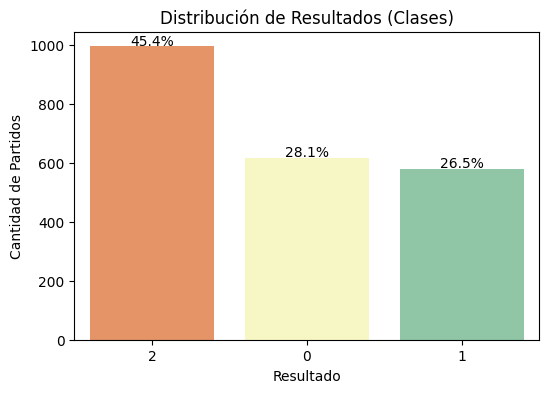

In [ ]:
# Suponiendo que tu variable objetivo se llama 'result' (valores como 'H', 'D', 'A' o 0, 1, 2)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='FTR_enc', data=df_match, palette="Spectral", order=df_match['FTR_enc'].value_counts().index)

# Añadir porcentajes sobre las barras
total = len(df_match)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 5), ha='center')

plt.title("Distribución de Resultados (Clases)")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de Partidos")
plt.show()

In [ ]:
# 1. Identificar columnas por patrones reales en el DataFrame
# (Esto evita tener que concatenar manualmente y cometer errores de nombres)
diff_cols_ready = [c for c in df_match.columns if c.endswith('_diff')]
ewm_diff_cols_ready = [c for c in df_match.columns if c.endswith('_ewm_5_diff')]

ewm_abs_diff_cols_ready = [c for c in df_match.columns if c.endswith('_ewm_5_abs_diff')]
position_diff_cols = ['table_position_diff']

# ewm_abs_diff_cols_ready.remove('yellow_cards_ewm_5_abs_diff')
# ewm_abs_diff_cols_ready.remove('red_cards_ewm_5_abs_diff')

# ewm_diff_cols_ready.remove('yellow_cards_ewm_5_diff')
# ewm_diff_cols_ready.remove('red_cards_ewm_5_diff')

rolling_cols = [c for c in df_match.columns if c.endswith('_last_5')]
# rolling_cols.remove('home_yellow_cards_last_5')
# rolling_cols.remove('away_red_cards_last_5')
# rolling_cols.remove('away_yellow_cards_last_5')
# rolling_cols.remove('home_red_cards_last_5')

# Columnas cíclicas
cyclical_cols = [c for c in df_match.columns if c.endswith('_sin') or c.endswith('_cos')]

# Columnas estáticas base
pos_cols = ['home_position_last', 'away_position_last']
xi_cols = [f'{t}_xi_{stat}' for t in ['home', 'away'] for stat in ['market_value', 'total_caps', 'average_height', 'average_age']]

xi_diff_cols = [
    'xi_market_value_diff', 'xi_total_caps_diff', 'xi_average_height_diff', 'xi_average_age_diff',
    'xi_market_value_abs_diff', 'xi_total_caps_abs_diff', 'xi_average_height_abs_diff', 'xi_average_age_abs_diff'
]

# 2. DEFINICIÓN REAL DE COLUMNAS PARA ESCALAR
# Incluimos absolutamente todas las variables numéricas continuas
numerical_cols_to_scale = pos_cols + xi_cols + ewm_diff_cols_ready + ewm_abs_diff_cols_ready

# Columnas que NO se deben escalar (las cíclicas ya van de -1 a 1)
cols_not_scale = cyclical_cols

#LISTA FINAL DE CARACTERÍSTICAS NUMÉRICAS (Unión limpia)
num_cols = numerical_cols_to_scale + cols_not_scale


## Creación de embeddings

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# listas donde guardaremos las entradas y embeddings
inputs = []
embeddings = []

# entradas para IDs de equipos local y visitante
home_team_in = layers.Input(shape=(1,), name="home_team_in")
away_team_in = layers.Input(shape=(1,), name="away_team_in")

# tamaño dinámico del embedding según nº de categorías
embedding_dim = lambda n: min(int(np.sqrt(n)) + 1, 16)

# número total de equipos únicos

n_teams = len(le_team.classes_)


team_embedding_layer = layers.Embedding(
    input_dim=n_teams,
    output_dim=embedding_dim(n_teams),
    name="team_embedding_shared"
)

# Aplicamos la MISMA capa a ambos inputs independientes
home_team_emb = team_embedding_layer(home_team_in)
away_team_emb = team_embedding_layer(away_team_in)

# Convertimos a 1D
home_team_emb = layers.Flatten()(home_team_emb)
away_team_emb = layers.Flatten()(away_team_emb)

# Guardamos
inputs += [home_team_in, away_team_in]
embeddings += [home_team_emb, away_team_emb]

In [ ]:
# entradas para managers local y visitante
home_manager_in = layers.Input(shape=(1,))
away_manager_in = layers.Input(shape=(1,))

n_managers = len(le_manager.classes_)

# Instanciamos la capa una vez para entrenadores
manager_embedding_layer = layers.Embedding(
    input_dim=n_managers,
    output_dim=embedding_dim(n_managers),
    name="manager_embedding_shared"
)

home_manager_emb = manager_embedding_layer(home_manager_in)
away_manager_emb = manager_embedding_layer(away_manager_in)

home_manager_emb = layers.Flatten()(home_manager_emb)
away_manager_emb = layers.Flatten()(away_manager_emb)

inputs += [home_manager_in, away_manager_in]
embeddings += [home_manager_emb, away_manager_emb]

In [ ]:
home_formation_in = layers.Input(shape=(1,), name="home_formation_in")
away_formation_in = layers.Input(shape=(1,), name="away_formation_in")

n_formations = len(le_formation.classes_)

# Instanciamos la capa una vez para formaciones (ej. 4-4-2, 4-3-3...)
formation_embedding_layer = layers.Embedding(
    input_dim=n_formations,
    output_dim=embedding_dim(n_formations),
    name="formation_embedding_shared"
)

home_formation_emb = formation_embedding_layer(home_formation_in)
away_formation_emb = formation_embedding_layer(away_formation_in)

home_formation_emb = layers.Flatten()(home_formation_emb)
away_formation_emb = layers.Flatten()(away_formation_emb)

inputs += [home_formation_in, away_formation_in]
embeddings += [home_formation_emb, away_formation_emb]

In [ ]:
# entrada para variables numéricas
num_in = layers.Input(shape=(len(num_cols),))

# guardar input numérico
inputs.append(num_in)

# añadir directamente las variables numéricas
embeddings.append(num_in)

# Estructura del modelo

In [ ]:
# unir embeddings y variables numéricas
x = layers.Concatenate()(embeddings)

# bloque denso principal
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.BatchNormalization()(x)

# segunda capa oculta
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization()(x)

# tercera capa oculta
x = layers.Dense(16, activation='relu')(x)
x = layers.Dropout(0.1)(x)

# salida multiclase: Home / Draw / Away
output = layers.Dense(3, activation='softmax')(x)

# construir modelo final
model = Model(inputs=inputs, outputs=output)
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.35, 0.38, 0.27])
# configuración de entrenamiento
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    #loss = 'categorical_crossentropy',
    loss = loss_fn,
    metrics=['accuracy']
)

# División de datos escalado de variables numericas

Nuestro dataframe fue ordenado por fecha anteriormente por lo que en la siguiente celda realizaremos la division de los datos de manera que en el entrenamiento solo se veran partidos ateriores a los presentes en los dataframes de validación y test.

In [ ]:
# ⚠️ IMPORTANTE: Split temporal, no random (evita data leakage en series temporales)
from sklearn.model_selection import train_test_split

# Dividir por fecha: 70% train, 15% val, 15% test
n_total = len(df_match)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)


# df_match ya está ordenado por fecha
df_train = df_match.iloc[:n_train].copy()
df_val = df_match.iloc[n_train:n_train+n_val].copy()
df_test = df_match.iloc[n_train+n_val:].copy()
df_demo = df_demo.iloc[n_train+n_val:]

scaler = StandardScaler()
#Escalado de variables numericas
df_train[numerical_cols_to_scale] = scaler.fit_transform(
    df_train[numerical_cols_to_scale]
)

df_val[numerical_cols_to_scale] = scaler.transform(
    df_val[numerical_cols_to_scale]
)

df_test[numerical_cols_to_scale] = scaler.transform(
    df_test[numerical_cols_to_scale]
)


In [ ]:
y = df_match['FTR_enc']

# Entrenamiento y pruebas

In [ ]:
# Función para organizar los datos de entrada de la red neuronal
def prepare_nn_inputs(df, num_cols, categorical_cols=['home_team_enc', 'away_team_enc',
                                                        'home_manager_enc', 'away_manager_enc',
                                                        'home_formation_enc', 'away_formation_enc']):
    """
    Prepara los inputs en el formato correcto para la red neuronal
    """
    inputs_dict = {}

    # Guardar las variables categóricas (para las capas de embeddings)
    inputs_dict['home_team'] = df['home_team_enc'].values
    inputs_dict['away_team'] = df['away_team_enc'].values
    inputs_dict['home_manager'] = df['home_manager_enc'].values
    inputs_dict['away_manager'] = df['away_manager_enc'].values
    inputs_dict['home_formation'] = df['home_formation_enc'].values
    inputs_dict['away_formation'] = df['away_formation_enc'].values

    # Guardar las variables numéricas juntas
    inputs_dict['numeric'] = df[num_cols].values

    return inputs_dict

# Procesar y estructurar los datos de entrenamiento, validación y prueba
train_inputs = prepare_nn_inputs(df_train, num_cols)
val_inputs = prepare_nn_inputs(df_val, num_cols)
test_inputs = prepare_nn_inputs(df_test, num_cols)

# Extraer las etiquetas con el resultado real de los partidos (0, 1 o 2)
y_train = df_train['FTR_enc'].values
y_val = df_val['FTR_enc'].values
y_test = df_test['FTR_enc'].values

# Importar herramientas para calcular pesos de clase y manejo de arrays
from sklearn.utils.class_weight import compute_class_weight


# Identificar las clases únicas (0, 1 y 2)
classes = np.unique(y_train)

# Calcular los pesos para equilibrar las clases desbalanceadas
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convertir los pesos calculados a un diccionario para Keras
class_weights = dict(enumerate(class_weights))

# Transformar las etiquetas a formato binario One-Hot Encode (ejemplo: 2 pasa a [0, 0, 1])
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_val_ohe = tf.keras.utils.to_categorical(y_val, num_classes=3)


# Mostrar en pantalla el tamaño total de los conjuntos de datos
print(f"X_train shape: {len(y_train)}, X_test shape: {len(y_test)}")

# Mostrar cuántos partidos hay de cada clase en el conjunto de entrenamiento
print(f"Distribución FTR en train:\n{pd.Series(y_train).value_counts().sort_index()}")

# Mostrar cuántos partidos hay de cada clase en el conjunto de prueba
print(f"Distribución FTR en test:\n{pd.Series(y_test).value_counts().sort_index()}")


X_train shape: 1535, X_test shape: 330
Distribución FTR en train:
0    427
1    416
2    692
Name: count, dtype: int64
Distribución FTR en test:
0     88
1     82
2    160
Name: count, dtype: int64


In [ ]:
import tensorflow as tf # Ensure tf is imported for to_categorical
from tensorflow.keras.callbacks import EarlyStopping

#
# Early stopping para evitar overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=70,
    restore_best_weights=True,
    verbose=1
)


# Entrenar el modelo
history = model.fit(
    x=[
        train_inputs['home_team'],
        train_inputs['away_team'],
        train_inputs['home_manager'],
        train_inputs['away_manager'],
        train_inputs['home_formation'],
        train_inputs['away_formation'],
        train_inputs['numeric']
    ],
    y=y_train_ohe, # Use one-hot encoded training labels
    validation_data=(
        [
            val_inputs['home_team'],
            val_inputs['away_team'],
            val_inputs['home_manager'],
            val_inputs['away_manager'],
            val_inputs['home_formation'],
            val_inputs['away_formation'],
            val_inputs['numeric']
        ],
        y_val_ohe
    ),
    epochs=200,
    batch_size= 32,
    #class_weight= class_weights,
    callbacks=[early_stop],
    verbose=1,

)

print(f"Mejor epoch: {len(history.history['loss']) - 10}")

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3661 - loss: 0.2892 - val_accuracy: 0.3435 - val_loss: 0.1642
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3785 - loss: 0.2869 - val_accuracy: 0.3404 - val_loss: 0.1695
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3935 - loss: 0.2632 - val_accuracy: 0.3343 - val_loss: 0.1753
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3883 - loss: 0.2509 - val_accuracy: 0.3526 - val_loss: 0.1796
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4091 - loss: 0.2398 - val_accuracy: 0.3617 - val_loss: 0.1815
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3922 - loss: 0.2476 - val_accuracy: 0.3708 - val_loss: 0.1817
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3746 - loss: 0.2465 - val_accuracy: 0.3891 - val_loss: 0.1811
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3681 - loss: 0.2490 - val_accuracy: 0.3799 - 

In [ ]:
model.input_shape

[(None, 1), (None, 1), (None, 1), (None, 1), (None, 1), (None, 1), (None, 38)]

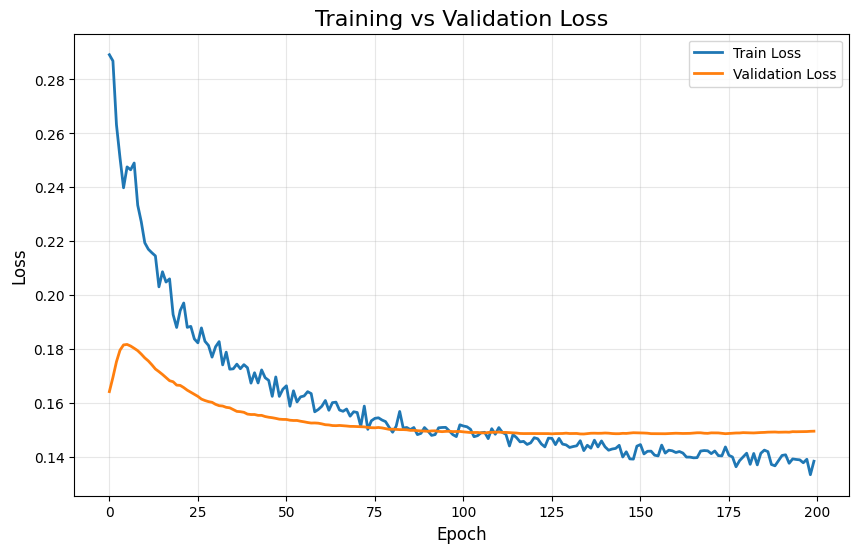

In [ ]:
import matplotlib.pyplot as plt

# gráfico de loss
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

# títulos y etiquetas
plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# grid y leyenda
plt.grid(True, alpha=0.3)
plt.legend()

# mostrar gráfico
plt.show()

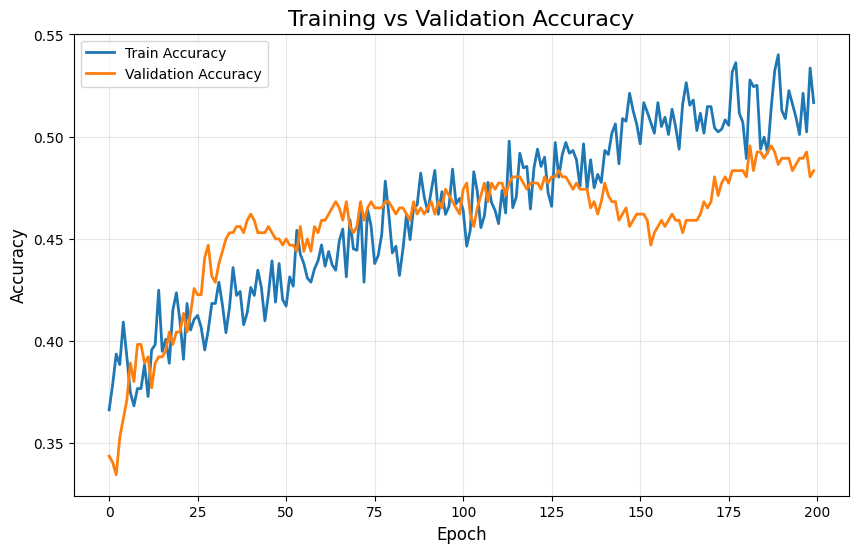

In [ ]:
import matplotlib.pyplot as plt

# gráfico de accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

# títulos y etiquetas
plt.title('Training vs Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# grid y leyenda
plt.grid(True, alpha=0.3)
plt.legend()

# mostrar gráfico
plt.show()

In [ ]:
model.save('modelo_tfg.keras')

In [ ]:
from sklearn.metrics import classification_report

pred_probs = model.predict([
    test_inputs['home_team'],
    test_inputs['away_team'],
    test_inputs['home_manager'],
    test_inputs['away_manager'],
    test_inputs['home_formation'],
    test_inputs['away_formation'],
    test_inputs['numeric']
])

preds = pred_probs.argmax(axis=1)

print(classification_report(y_test, preds))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

           0       0.40      0.38      0.39        88
           1       0.29      0.33      0.31        82
           2       0.58      0.56      0.57       160

    accuracy                           0.45       330
   macro avg       0.42      0.42      0.42       330
weighted avg       0.46      0.45      0.46       330



<Axes: >

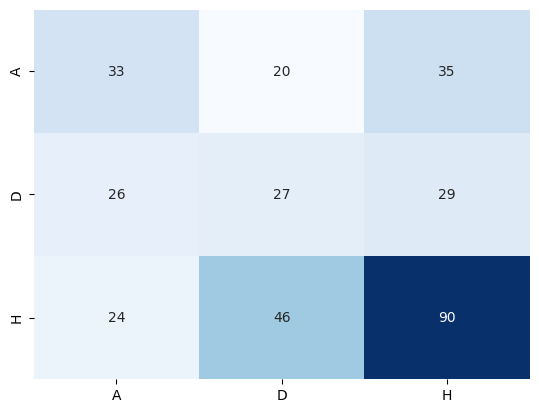

In [ ]:
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
confusion_matrix(y_test, preds)
sns.heatmap(
    confusion_matrix(y_test, preds),
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_

)




In [ ]:
import joblib
model_metadata = {
    "num_cols": num_cols,

    "embedding_inputs": {
        "home_team": "home_team_enc",
        "away_team": "away_team_enc",

        "home_manager": "home_manager_enc",
        "away_manager": "away_manager_enc",

        "home_formation": "home_formation_enc",
        "away_formation": "away_formation_enc",

        "home_club_id": "home_club_id_enc",
        "away_club_id": "away_club_id_enc"
    },

    "target_classes": le_target.classes_.tolist()
}
joblib.dump(model_metadata, "model_metadata.pkl")




joblib.dump(scaler, "scaler.pkl")


encoders = {
    "team": le_team,
    "manager": le_manager,
    "formation": le_formation,
    "club": le_club,
    "target": le_target
}

joblib.dump(encoders, "encoders.pkl")


df_demo.to_csv( "partidos_demo_web.csv", index=False )
df_demo.columns

['home_position_last',
 'away_position_last',
 'home_xi_market_value',
 'home_xi_total_caps',
 'home_xi_average_height',
 'home_xi_average_age',
 'away_xi_market_value',
 'away_xi_total_caps',
 'away_xi_average_height',
 'away_xi_average_age',
 'shots_ewm_5_diff',
 'shots_target_ewm_5_diff',
 'corners_ewm_5_diff',
 'fouls_ewm_5_diff',
 'xp_ewm_5_diff',
 'xg_ewm_5_diff',
 'np_xg_ewm_5_diff',
 'ppda_ewm_5_diff',
 'deep_completions_ewm_5_diff',
 'month_sin',
 'month_cos',
 'dow_sin',
 'dow_cos',
 'hour_sin',
 'hour_cos']

In [ ]:
import os


drive_folder = '/content/drive/MyDrive/models'
os.makedirs(drive_folder, exist_ok=True)

# lista de archivos
archivos_a_subir = [
    "model_metadata.pkl",
    "scaler.pkl",
    "encoders.pkl",
    "partidos_demo_web.csv",
    "modelo_tfg.keras"
]

# Mover y copiar los archivos a Google Drive
import shutil

print("Iniciando la subida de archivos a Google Drive...")
for archivo in archivos_a_subir:
    if os.path.exists(archivo):
        destino = os.path.join(drive_folder, archivo)
        shutil.copy(archivo, destino)
        print(f"¡Subido con éxito!: {archivo} -> {destino}")
    else:
        print(f" Error: El archivo '{archivo}' no se encontró en el entorno local.")

print("\n Todos los artefactos del modelo están respaldados de forma segura en tu Drive.")


Iniciando la subida de archivos a Google Drive...
¡Subido con éxito!: model_metadata.pkl -> /content/drive/MyDrive/models/model_metadata.pkl
¡Subido con éxito!: scaler.pkl -> /content/drive/MyDrive/models/scaler.pkl
¡Subido con éxito!: encoders.pkl -> /content/drive/MyDrive/models/encoders.pkl
¡Subido con éxito!: partidos_demo_web.csv -> /content/drive/MyDrive/models/partidos_demo_web.csv
¡Subido con éxito!: modelo_tfg.keras -> /content/drive/MyDrive/models/modelo_tfg.keras

 Todos los artefactos del modelo están respaldados de forma segura en tu Drive.
